In [1]:
import pandas as pd
import numpy as np
import os

file_name = "processed_ar.csv"
data_path = os.path.join('../datasets/processed/', file_name)

df = pd.read_csv(data_path)
df.head()

,countryCode,customerID,invoiceNumber,InvoiceAmount,PaperlessBill,CreditTermDays,InvoiceMonth,InvoiceDayOfWeek,InvoiceQuarter,DaysSincePaperless,CustomerFreq,target
0,391,6708-DPYTF,5133177585,55.37,Paper,30,1,1,1,0,0,0
1,770,3993-QUNVJ,280670965,50.39,Paper,30,1,1,1,0,0,0
2,406,5164-VMYWJ,6393629835,71.33,Paper,30,1,1,1,0,0,0
3,818,1604-LIFKX,5928070131,97.60,Paper,30,1,1,1,0,0,0
4,818,8887-NCUZC,6050714721,15.99,Paper,30,1,1,1,0,0,1


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

CATEGORICAL = ['countryCode', 'PaperlessBill']
NUMERIC     = ['InvoiceAmount', 'CreditTermDays', 'InvoiceMonth',
                'InvoiceDayOfWeek', 'InvoiceQuarter', 'DaysSincePaperless', 'CustomerFreq']

X = df[CATEGORICAL + NUMERIC].copy()
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Preprocessors
preprocess_lr = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
        ('num', StandardScaler(), NUMERIC),
    ]
)
preprocess_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
    ],
    remainder='passthrough'
)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (1972, 9) | Test: (494, 9)


In [3]:
# SelectKBest: pick the k most informative features (ANOVA F-test)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Refined Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocess', preprocess_lr),
    ('select',     SelectKBest(f_classif)),
    ('model',      LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])

lr_param_grid = {
    'select__k': [5, 7, 9, 'all'],
    'model__C':  [0.01, 0.1, 1.0, 10.0],
}

lr_grid = GridSearchCV(
    lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_

print('LR Best Params:', lr_grid.best_params_)
print('LR Best CV F1 :', lr_grid.best_score_.round(4))

LR Best Params: {'model__C': 1.0, 'select__k': 'all'}
LR Best CV F1 : 0.4879


C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [4]:
#Refined Random Forest optimise for Precision (collections use case)
rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocess_rf),
    ('select',     SelectKBest(f_classif)),
    ('model',      RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1
    )),
])

rf_param_grid = {
    'select__k':             [5, 7, 9, 'all'],
    'model__n_estimators':   [200, 300, 400],
    'model__max_depth':      [None, 10, 20],
    'model__min_samples_split': [2, 4, 8],
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='precision',
    n_jobs=1          # keep sequential to avoid memory spikes
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

print('RF Best Params:    ', rf_grid.best_params_)
print('RF Best CV Precision:', rf_grid.best_score_.round(4))

C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\loc

RF Best Params:     {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 400, 'select__k': 'all'}
RF Best CV Precision: 0.5481


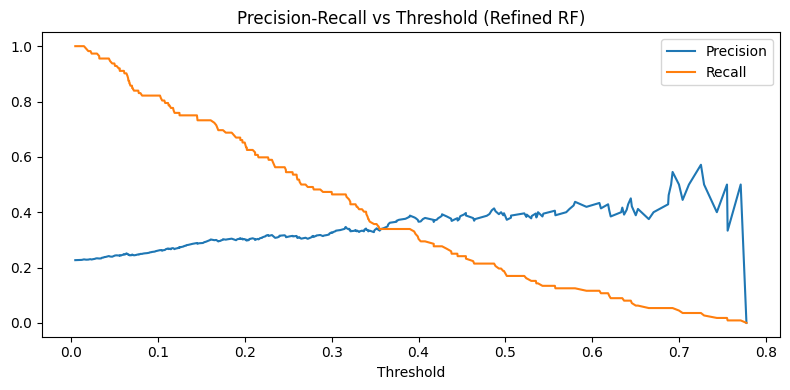

Calibrated threshold: 0.691  →  Precision=0.5000, Recall=0.0536


In [5]:
# Threshold calibration for Random Forest
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1],    label='Recall')
plt.xlabel('Threshold')
plt.title('Precision-Recall vs Threshold (Refined RF)')
plt.legend()
plt.tight_layout()
plt.show()

# Pick the lowest threshold where Precision >= 0.50
target_precision = 0.50
valid = [(t, p, r) for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds)
         if p >= target_precision]
if valid:
    best_t, best_p, best_r = min(valid, key=lambda x: x[0])
    print(f'Calibrated threshold: {best_t:.3f}  →  Precision={best_p:.4f}, Recall={best_r:.4f}')
else:
    best_t = 0.5
    print('No threshold achieves target precision; keeping default 0.50')

In [6]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay
)

# Apply calibrated threshold to RF
y_pred_rf_cal = (y_prob_rf >= best_t).astype(int)

y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

rows = []
for name, y_pred, y_prob in [
    ('LR — Refined',      y_pred_lr,     y_prob_lr),
    ('RF — Refined (cal)', y_pred_rf_cal, y_prob_rf),
]:
    rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
    })

results = pd.DataFrame(rows)
print(results.to_string(index=False))

             Model  Accuracy  Precision  Recall     F1  ROC-AUC
      LR — Refined    0.6518     0.3544  0.6518 0.4591   0.6931
RF — Refined (cal)    0.7733     0.5000  0.0536 0.0968   0.6326


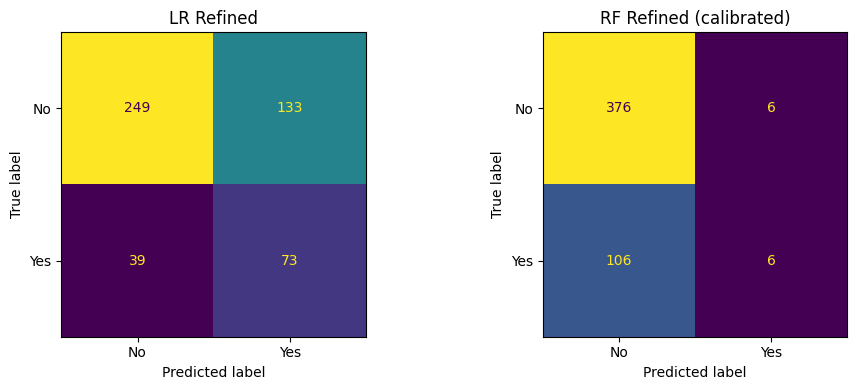

In [7]:
# Confusion matrices 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, y_pred) in zip(axes, [
    ('LR Refined', y_pred_lr),
    ('RF Refined (calibrated)', y_pred_rf_cal),
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['No', 'Yes'],
        colorbar=False, ax=ax
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

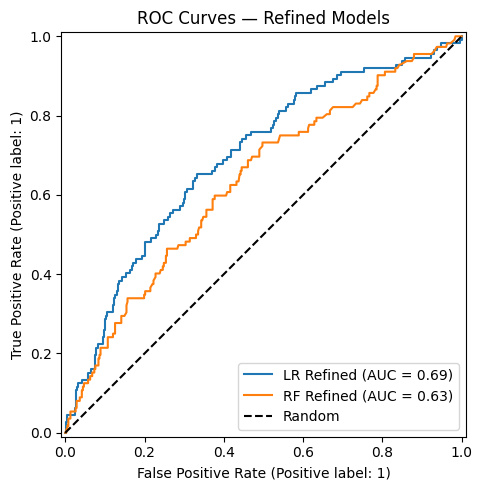

In [8]:
#ROC curves
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))
for name, y_prob in [('LR Refined', y_prob_lr), ('RF Refined', y_prob_rf)]:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC Curves — Refined Models')
ax.legend()
plt.tight_layout()
plt.show()


=== Top Feature Importances ===
                 feature  importance
           InvoiceAmount    0.270333
            CustomerFreq    0.184547
        InvoiceDayOfWeek    0.118255
      DaysSincePaperless    0.112202
            InvoiceMonth    0.111480
          InvoiceQuarter    0.044173
         countryCode_391    0.040402
         countryCode_406    0.039584
         countryCode_818    0.027389
         countryCode_770    0.016576
         countryCode_897    0.013786
PaperlessBill_Electronic    0.010726
     PaperlessBill_Paper    0.010547
          CreditTermDays    0.000000


<Figure size 800x500 with 0 Axes>

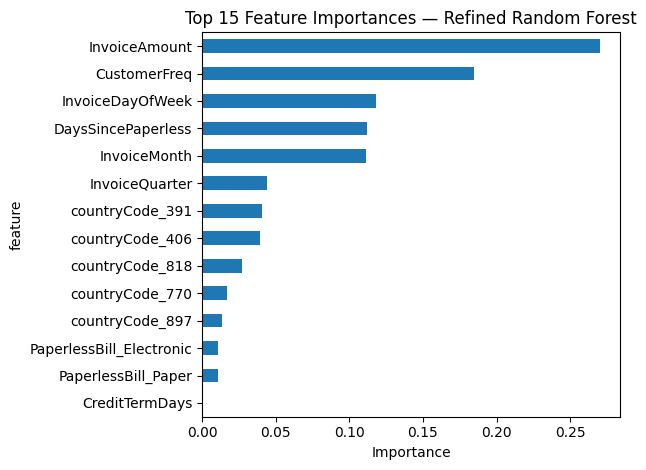

In [9]:
# Feature importance (Refined RF) 
rf_model = best_rf.named_steps['model']
pre      = best_rf.named_steps['preprocess']
sel      = best_rf.named_steps['select']

ohe_names = pre.named_transformers_['cat'].get_feature_names_out(CATEGORICAL).tolist()
num_names = NUMERIC
all_names = ohe_names + num_names
selected_names = [n for n, s in zip(all_names, sel.get_support()) if s]

fi = pd.DataFrame({
    'feature':    selected_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print('\n=== Top Feature Importances ===')
print(fi.head(15).to_string(index=False))

plt.figure(figsize=(8, 5))
fi.head(15).plot(kind='barh', x='feature', y='importance', legend=False)
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — Refined Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [10]:
# Save model and feature_info.json 
import json
import joblib

os.makedirs('../../models', exist_ok=True)

model_path = '../../models/random_forest_dispute_model.pkl'
joblib.dump(best_rf, model_path)

categorical_values = {
    col: sorted(X[col].dropna().astype(str).unique().tolist())
    for col in CATEGORICAL
}

feature_info = {
    'all_features':          CATEGORICAL + NUMERIC,
    'categorical_features':  CATEGORICAL,
    'numeric_features':      NUMERIC,
    'categorical_values':    categorical_values,
    'target':                'Disputed',
    'classes':               ['No', 'Yes'],
    'operating_threshold':   round(float(best_t), 4),
}

with open('../../models/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print('Model saved to:', model_path)
print('feature_info.json saved.')
print(json.dumps(feature_info, indent=2))

Model saved to: ../../models/random_forest_dispute_model.pkl
feature_info.json saved.
{
  "all_features": [
    "countryCode",
    "PaperlessBill",
    "InvoiceAmount",
    "CreditTermDays",
    "InvoiceMonth",
    "InvoiceDayOfWeek",
    "InvoiceQuarter",
    "DaysSincePaperless",
    "CustomerFreq"
  ],
  "categorical_features": [
    "countryCode",
    "PaperlessBill"
  ],
  "numeric_features": [
    "InvoiceAmount",
    "CreditTermDays",
    "InvoiceMonth",
    "InvoiceDayOfWeek",
    "InvoiceQuarter",
    "DaysSincePaperless",
    "CustomerFreq"
  ],
  "categorical_values": {
    "countryCode": [
      "391",
      "406",
      "770",
      "818",
      "897"
    ],
    "PaperlessBill": [
      "Electronic",
      "Paper"
    ]
  },
  "target": "Disputed",
  "classes": [
    "No",
    "Yes"
  ],
  "operating_threshold": 0.6907
}
